In [1]:

# from plotPipe import drawPipeline, createGraph, createLogicalDependencyGraph, createLogicalDependencyGraphOfNanoOps, createLogicalDependencyGraphOfLayeredNanoOps\
#     ,calcStartEndLayered,getCycleTime,drawPipelineLayered,createGraphOfLayeredNanoOps
from operation import Operation, NanoOperation, Dependency, LayeredOperation, NanoOperationSecondStage
from itertools import accumulate
from typing import Dict

hdim=4096
idim=14336
ngpu=1
hsplit = hdim // ngpu
isplit = idim // ngpu
kqv_n = int(hsplit * 1.5)

global_batch_size = 1024
decode_batch_size = 384
prefill_batch_size = 640

In [2]:
batch_size_range = list(range(128, global_batch_size+1, 128))
# create operations
operations:list[Operation] = [
    Operation("KQV", 0, global_batch_size, [Dependency("D", True)], "gemm", (kqv_n, hdim), batch_size_range),
    Operation("GEMV", 0, decode_batch_size, [Dependency("KQV")], "gemv", (0,0,0), batch_size_range),
    Operation("PF", 384, prefill_batch_size, [Dependency("KQV")], "gemv", (0,0,0), batch_size_range),
    Operation("O", 0, global_batch_size, [Dependency("GEMV"), Dependency("PF")], "gemm", (hsplit, hdim), batch_size_range),
    Operation("UG", 0, global_batch_size, [Dependency("O")], "gemm", (2*isplit, hdim), batch_size_range),
    Operation("D", 0, global_batch_size, [Dependency("UG")], "gemm", (hdim, isplit), batch_size_range),
]

nano_operation_num_map = {
    "KQV": 2,
    "GEMV": 1,
    "PF": 1,
    "O": 2,
    "UG": 2,
    "D": 2
}

for op in operations:
    op.nano_operations = []
    op.num_nano_batch = nano_operation_num_map[op.name]
    
# create a map from name to operation
operation_map = {}
for op in operations:
    operation_map[op.name] = op

for op in operations:
    op.depend_on_operations = []
    for dep in op.depends_on:
        if isinstance(dep, Dependency):
            op.depend_on_operations.append(Dependency(operation_map[dep.operation], dep.depend_on_previous_layer))

In [3]:
# read profile
from profileAnalysis import getGemvTime, getAllReduceProfile, getAllgatherProfile, getGemmProfile

getGemmProfile((640, 1024, 8192), ("RowMajor", "RowMajor", "RowMajor"))


,M,N,K,cta_m,cta_n,cta_k,warp_m,warp_n,warp_k,split,stage,A_layout,B_layout,D_layout,time,GFLOPs,blocks,allSMTflops,tag
0,640,1024,8192,128,256,32,64,64,32,1,3,RowMajor,RowMajor,RowMajor,0.197054,54489.6,20.0,294243.84,128_256_32_64_64_32_1_3_RowMajor_RowMajor_RowM...
1,640,1024,8192,128,128,32,64,64,32,1,5,RowMajor,RowMajor,RowMajor,0.102480,104776.0,40.0,282895.20,128_128_32_64_64_32_1_5_RowMajor_RowMajor_RowM...
2,640,1024,8192,128,256,32,64,64,32,3,3,RowMajor,RowMajor,RowMajor,0.082161,130688.0,60.0,235238.40,128_256_32_64_64_32_3_3_RowMajor_RowMajor_RowM...
3,640,1024,8192,128,128,32,64,64,32,2,5,RowMajor,RowMajor,RowMajor,0.059951,179103.0,80.0,241789.05,128_128_32_64_64_32_2_5_RowMajor_RowMajor_RowM...
4,640,1024,8192,128,128,32,64,64,32,5,5,RowMajor,RowMajor,RowMajor,0.058306,184158.0,200.0,99445.32,128_128_32_64_64_32_5_5_RowMajor_RowMajor_RowM...


In [4]:
def getGEMV8B(batch, seqlen, blk):
    return getGemvTime(batch//2, seqlen//2, blk)[0]
def getGEMV70B(batch, seqlen, blk):
    return getGemvTime(batch//8, seqlen//4, blk)[0]

In [5]:
for block in [25, 50, 75, 108]:
    print(getGEMV70B(1408, 1024, block))
    print(getGEMV8B(341, 1280, block))

1.69399076247565
2.6868925344868755
0.9062862034614407
1.456948953105951
0.6300705895777945
1.1383173523620869
0.48339196945043744
1.0801430725336048


In [6]:
category_list = ["gemm", "gemv"]
category_op_map: dict[str, list[Operation]] = {}
for category in category_list:
    category_op_map[category] = []
for op in operations:
    category_op_map[op.category].append(op)

In [7]:
getGemmProfile((640, 1024, 8192), ("RowMajor", "RowMajor", "RowMajor"))

,M,N,K,cta_m,cta_n,cta_k,warp_m,warp_n,warp_k,split,stage,A_layout,B_layout,D_layout,time,GFLOPs,blocks,allSMTflops,tag
0,640,1024,8192,128,256,32,64,64,32,1,3,RowMajor,RowMajor,RowMajor,0.197054,54489.6,20.0,294243.84,128_256_32_64_64_32_1_3_RowMajor_RowMajor_RowM...
1,640,1024,8192,128,128,32,64,64,32,1,5,RowMajor,RowMajor,RowMajor,0.102480,104776.0,40.0,282895.20,128_128_32_64_64_32_1_5_RowMajor_RowMajor_RowM...
2,640,1024,8192,128,256,32,64,64,32,3,3,RowMajor,RowMajor,RowMajor,0.082161,130688.0,60.0,235238.40,128_256_32_64_64_32_3_3_RowMajor_RowMajor_RowM...
3,640,1024,8192,128,128,32,64,64,32,2,5,RowMajor,RowMajor,RowMajor,0.059951,179103.0,80.0,241789.05,128_128_32_64_64_32_2_5_RowMajor_RowMajor_RowM...
4,640,1024,8192,128,128,32,64,64,32,5,5,RowMajor,RowMajor,RowMajor,0.058306,184158.0,200.0,99445.32,128_128_32_64_64_32_5_5_RowMajor_RowMajor_RowM...


In [8]:

import math
for gemm_op in category_op_map["gemm"]:
    for batch_size in batch_size_range:
        df = getGemmProfile((batch_size, gemm_op.fixed_shape[0], gemm_op.fixed_shape[1]), ("RowMajor", "RowMajor", "RowMajor"))
        # get last row of the dataframe
        last_row = df.iloc[-1]
        gemm_op.duration_map[(batch_size, 1)] = last_row["time"]
        for i in range(1, 10, 2):
            p = i/10
            gemm_op.duration_map[(batch_size, p)] = last_row["time"] / math.sqrt(p)
        

for batch_size in batch_size_range:
    operation_map["GEMV"].duration_map[(batch_size, 1)] = getGEMV8B(batch_size, 1024, 108)
    for i in range(1, 10, 2):
        p = i/10
        operation_map["GEMV"].duration_map[(batch_size, p)] = getGEMV8B(batch_size, 1024, 108) / math.sqrt(p)

for batch_size in batch_size_range:
    operation_map["PF"].duration_map[(batch_size, 1)] = 100/1000/ global_batch_size * batch_size
    for i in range(1, 10, 2):
        p = i/10
        operation_map["PF"].duration_map[(batch_size, p)] = 100/1000/ global_batch_size * batch_size / math.sqrt(p)

In [9]:
# get layered operation
layer_num = 3
all_layered_ops: list[LayeredOperation] = []
op_to_layered_op_map: Dict[Operation, Dict[int,LayeredOperation]] = {}
for op in operations:
    for l in range(layer_num):
        layered_op = LayeredOperation(op, l)
        all_layered_ops.append(layered_op)
        if op not in op_to_layered_op_map:
            op_to_layered_op_map[op] = {}
        op_to_layered_op_map[op][l] = layered_op

for lop in all_layered_ops:
    lop.depend_on_operations = []
    count = 0
    for dep_op in lop.operation.depend_on_operations:
        if dep_op.depend_on_previous_layer:
            if lop.layer > 0:
                lop.depend_on_operations.append(op_to_layered_op_map[dep_op.operation][lop.layer-1])
        else:
            lop.depend_on_operations.append(op_to_layered_op_map[dep_op.operation][lop.layer])

In [10]:
# begin stage 1 from now on, use lop

min_start_batch = min([op.operation.start_batch for op in all_layered_ops])
max_end_batch = max([op.operation.start_batch + op.operation.batch_size for op in all_layered_ops])

# Fixed chunk size
chunk_size = 128

# Create global batch chunks
global_batch_chunks = list(range(min_start_batch, max_end_batch, chunk_size))

# Map operations to global chunks
for op in all_layered_ops:
    op.operation.batch_chunks = [c for c in global_batch_chunks if op.operation.start_batch <= c < op.operation.start_batch + op.operation.batch_size]


In [11]:
# create nanooperations
all_nano_ops: list[NanoOperation] = []
nano_op_map: Dict[LayeredOperation, Dict[int, NanoOperation]] = {}
for op in all_layered_ops:
    for i in range(op.operation.num_nano_batch):
        nano_op = NanoOperation(i, op)
        all_nano_ops.append(nano_op)
        if op not in nano_op_map:
            nano_op_map[op] = {}
        nano_op_map[op][i] = nano_op

In [12]:
import gurobipy as gp
from gurobipy import GRB
import itertools    
model = gp.Model("pipeline")
for nano_op in all_nano_ops:
    nano_op.initVariables(model) # add assign, batch_size, start_time, end_time, duration, batch_size_choice, num_chunks_assigned
    
# create sequantial constraints
sequence_nano = {}
category_nano_op_map: dict[str, list[NanoOperation]] = {}
for category in category_list:
    category_nano_op_map[category] = []
for nano_op in all_nano_ops:
    category_nano_op_map[nano_op.operation.category].append(nano_op)

for category in category_list:
    nano_ops = category_nano_op_map[category]
    for op_1, op_2 in itertools.combinations(nano_ops, 2):
        sequence_nano[op_1, op_2] = model.addVar(vtype=GRB.BINARY, name=f"{op_1.name}_before_{op_2.name}")

overlap_chunk = {}
# overlap chunk constraints
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        overlap_chunk[op1, op2] = model.addVar(vtype=GRB.BINARY, name=f"{op1.name}_overlap_chunk_with_{op2.name}")
    
C_max = model.addVar(vtype=GRB.CONTINUOUS, name="C_max")

Set parameter Username
Set parameter LicenseID to value 2586842
Academic license - for non-commercial use only - expires 2025-11-19


In [13]:
for nano_op in all_nano_ops:
    nano_op.addInternalConstraints(model, chunk_size)

In [14]:
# nanobatch partitions lop input
for lop in all_layered_ops:
    for c in lop.operation.batch_chunks:
        nano_op_list = nano_op_map[lop].values()
        model.addConstr(gp.quicksum([nano_op.assign[c] for nano_op in nano_op_list]) == 1, 
                        name=f"partition_{lop.name}_nano_{c}")

In [15]:
M = 1e6
# non-overlapping constraints
for type_name, nano_op_list in category_nano_op_map.items():
    for op1, op2 in itertools.combinations(nano_op_list, 2):
        model.addConstr(op1.end_time <= op2.start_time + 10 * (1 - sequence_nano[op1, op2]),
                        name=f"non_overlap_{op1.name}_{op2.name}_when_sequence_nano_1")
        model.addConstr(op2.end_time <= op1.start_time + 10 * sequence_nano[op1, op2],
                        name=f"non_overlap_{op1.name}_{op2.name}_when_sequence_nano_2")

In [16]:
# # detect overlap chunk
# for op1 in all_nano_ops:
#     for op2 in all_nano_ops:
#         if op1 == op2:
#             continue
#         common_chunks = set(op1.operation.batch_chunks).intersection(set(op2.operation.batch_chunks))
#         if common_chunks:
#             model.addConstr(overlap_chunk[op1, op2] >= gp.quicksum(op1.assign[c] * op2.assign[c] for c in common_chunks) / len(common_chunks),
#                             name=f"overlap_chunk_{op1.name}_{op2.name}")
#         else:
#             model.addConstr(overlap_chunk[op1, op2] == 0,
#                             name=f"overlap_chunk_{op1.name}_{op2.name}")

In [17]:
# Detect overlap chunk using link variables
link_assign = {}
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        common_chunks = set(op1.operation.batch_chunks).intersection(set(op2.operation.batch_chunks))
        if common_chunks:
            # Create link variables for each common chunk
            for c in common_chunks:
                link_var_name = f"link_{op1.name}_{op2.name}_{c}"
                link_assign[op1, op2, c] = model.addVar(vtype=GRB.BINARY, name=link_var_name)
                
                # Constraints to linearize the product op1.assign[c] * op2.assign[c]
                model.addConstr(link_assign[op1, op2, c] <= op1.assign[c], name=f"link_constr1_{link_var_name}")
                model.addConstr(link_assign[op1, op2, c] <= op2.assign[c], name=f"link_constr2_{link_var_name}")
                model.addConstr(link_assign[op1, op2, c] >= op1.assign[c] + op2.assign[c] - 1, name=f"link_constr3_{link_var_name}")
            
            # Overlap chunk constraint using link variables
            model.addConstr(
                overlap_chunk[op1, op2] >= gp.quicksum(link_assign[op1, op2, c] for c in common_chunks) / len(common_chunks),
                name=f"overlap_chunk_{op1.name}_{op2.name}")
        else:
            model.addConstr(
                overlap_chunk[op1, op2] == 0,
                name=f"overlap_chunk_{op1.name}_{op2.name}")


In [18]:
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations:
            model.addConstr(op1.start_time >= op2.end_time - 10 * (1 - overlap_chunk[op1, op2]),
                            name=f"overlap_chunk_{op1.name}_{op2.name}_when_depend_on")

In [19]:
for op1, op2 in itertools.combinations(all_nano_ops, 2):
    if op1 == op2:
        continue
    if op1.operation == op2.operation and op1.idx == op2.idx: # only different by the layer
        for c in op1.operation.batch_chunks:
            model.addConstr(op1.assign[c] == op2.assign[c] , name=f"same_nano_same_assignment{op1.name}_{op2.name}")

In [20]:
for op in all_nano_ops:
    model.addConstr(C_max >= op.end_time, name=f"update_C_max_{op.name}")

In [21]:
model.setObjective(C_max, GRB.MINIMIZE)
model.setParam("Threads", 200)
# model.setParam("TimeLimit", 120)
model.optimize()

Set parameter Threads to value 200
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 9554 64-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 127 physical cores, 255 logical processors, using up to 200 threads

Non-default parameters:
Threads  200

Optimize a model with 18872 rows, 7354 columns and 49536 nonzeros
Model fingerprint: 0xe14ec733
Variable types: 121 continuous, 7233 integer (7233 binary)
Coefficient statistics:
  Matrix range     [1e-02, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+01]
Presolve removed 17788 rows and 6680 columns
Presolve time: 0.13s
Presolved: 1084 rows, 674 columns, 3726 nonzeros
Variable types: 55 continuous, 619 integer (619 binary)

Root relaxation: objective 1.073281e+00, 437 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth In

In [22]:
# print durations
for op in all_nano_ops:
    print(op)

KQV_0_0 start: 0.138 end: 0.222 duration: 0.084 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_0_1 start: 0.000 end: 0.138 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
KQV_1_0 start: 1.864 end: 1.947 duration: 0.084 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_1_1 start: 1.136 end: 1.274 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
KQV_2_0 start: 3.589 end: 3.673 duration: 0.084 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_2_1 start: 2.861 end: 3.000 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
GEMV_0_0 start: 0.222 end: 1.219 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_1_0 start: 2.003 end: 3.000 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_2_0 start: 3.673 end: 4.669 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
PF_0

KQV_0_0 start: 0.156 end: 0.212 duration: 0.0557 batch_size: 256 batch_size_choice: 256 chunk_id: 128 256
KQV_0_1 start: 0.0 end: 0.156 duration: 0.156 batch_size: 768 batch_size_choice: 768 chunk_id: 0 384 512 640 768 896
KQV_1_0 start: 1.13 end: 1.27 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
KQV_1_1 start: 1.86 end: 1.94 duration: 0.0839 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_2_0 start: 3.59 end: 3.67 duration: 0.0839 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
KQV_2_1 start: 2.86 end: 3.0 duration: 0.138 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
GEMV_0_0 start: 0.274 end: 1.27 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_1_0 start: 1.94 end: 2.94 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
GEMV_2_0 start: 3.67 end: 4.67 duration: 0.997 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
PF_0_0 start: 0.156 end: 0.219 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
PF_1_0 start: 1.5 end: 1.56 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
PF_2_0 start: 3.0 end: 3.06 duration: 0.0625 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_0_0 start: 0.219 end: 0.307 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_0_1 start: 1.27 end: 1.33 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_1_0 start: 1.94 end: 2.03 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
O_1_1 start: 3.0 end: 3.05 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_2_0 start: 4.67 end: 4.72 duration: 0.0561 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
O_2_1 start: 3.67 end: 3.76 duration: 0.0887 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_0_0 start: 0.307 end: 0.863 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_0_1 start: 1.33 end: 1.68 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
UG_1_0 start: 2.03 end: 2.59 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_1_1 start: 3.05 end: 3.41 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
UG_2_0 start: 3.76 end: 4.31 duration: 0.555 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
UG_2_1 start: 4.72 end: 5.08 duration: 0.356 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_0_0 start: 1.68 end: 1.86 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_0_1 start: 0.863 end: 1.13 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
D_1_0 start: 3.41 end: 3.59 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_1_1 start: 2.59 end: 2.86 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896
D_2_0 start: 5.08 end: 5.25 duration: 0.177 batch_size: 384 batch_size_choice: 384 chunk_id: 0 128 256
D_2_1 start: 4.31 end: 4.58 duration: 0.27 batch_size: 640 batch_size_choice: 640 chunk_id: 384 512 640 768 896

In [23]:
# # print all overlap variables in a 2D matrix
# for op1 in all_nano_ops:
#     for op2 in all_nano_ops:
#         if op1 == op2:
#             continue
#         if overlap_chunk[op1, op2].x > 0.5:
#             print(f"{op1.name} overlaps with {op2.name}")

In [24]:
# for op1 in all_nano_ops:
# for op2 in all_nano_ops:
#     if op1 == op2:
#         continue
#     if op2.layered_operation in op1.layered_operation.depend_on_operations:
#         print(f"{op1.name} depend on {op2.name}")
#         model.addConstr(op1.start_time >= op2.end_time - M * (1 - overlap_chunk[op1, op2]),
#                         name=f"overlap_chunk_{op1.name}_{op2.name}_when_depend_on")
# verify the solution
for op1 in all_nano_ops:
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations and overlap_chunk[op1, op2].x > 0.5:
            if op1.start_time.x <= op2.end_time.x - 0.001:
                print(f"overlap chunk between {op1.name} and {op2.name} is not correct")
            # else:
            #     print(f"overlap chunk between {op1.name} and {op2.name} is correct")

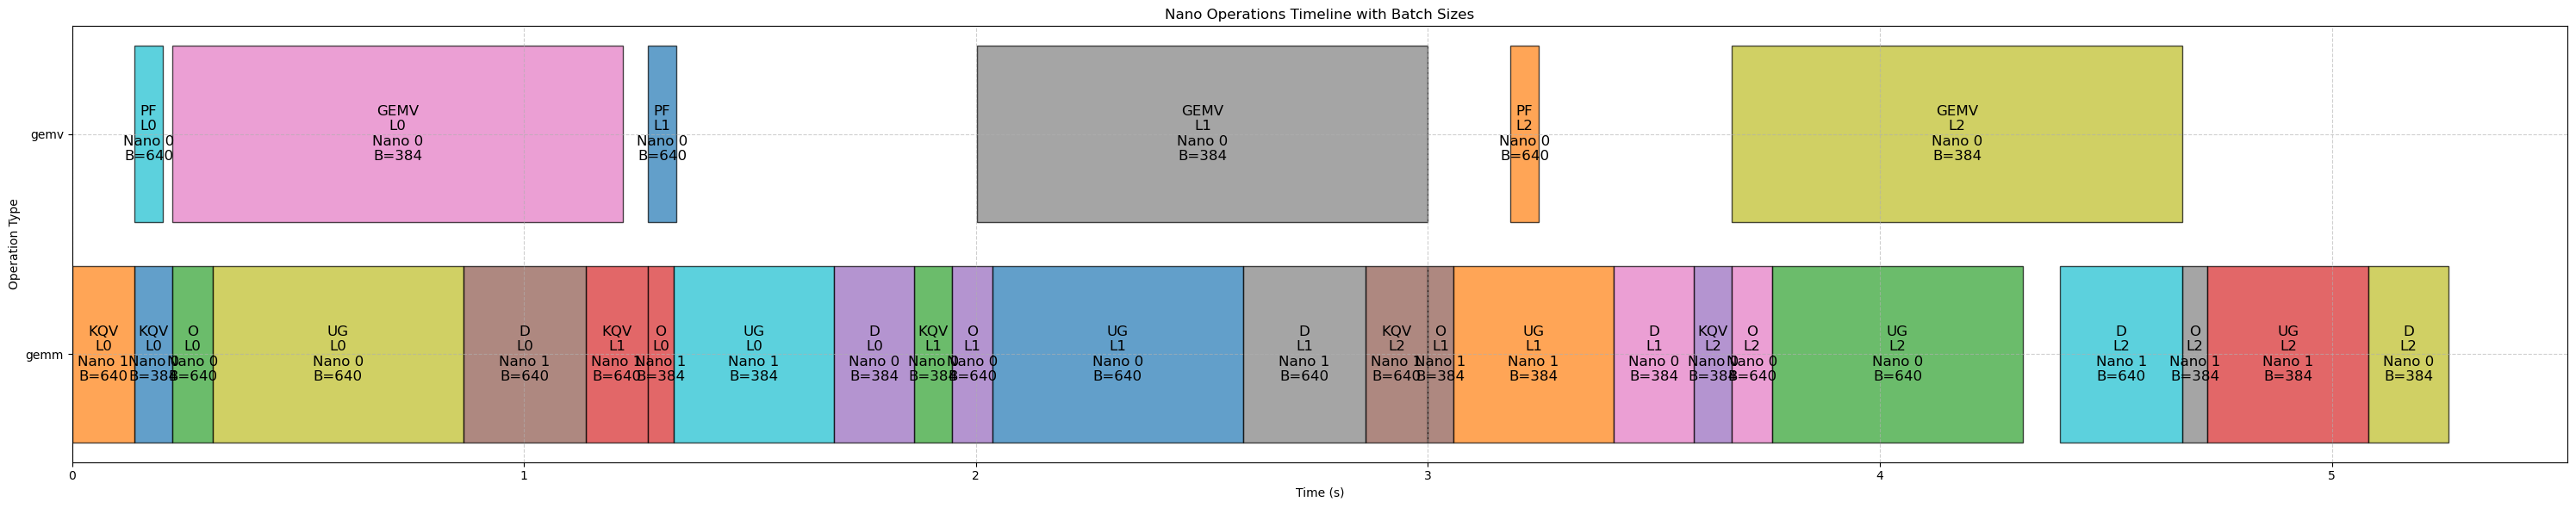

In [25]:
from matplotlib import pyplot as plt

# Assuming you have a list of NanoOperation instances called nano_operations_list
# and each NanoOperation has the required attributes.

# Extract unique operation types
operation_types = sorted(set(n.operation.category for n in all_nano_ops))
y_positions = {op_type: i for i, op_type in enumerate(operation_types)}

fig, ax = plt.subplots(figsize=(30, 6))

for n in all_nano_ops:
    n_name = n.name
    # Access the optimized values of the variables
    start_time = n.start_time.X
    duration = n.duration.X
    batch_size = n.batch_size.X
    op_type = n.operation.category  # Assuming 'category' is the type

    y_position = y_positions[op_type]
    
    # Plot the operation as a horizontal bar
    ax.barh(y_position, duration, left=start_time, height=0.8, alpha=0.7, edgecolor="black")
    
    # Annotate with operation name and batch size
    label = f"{n.operation.name}\nL{n.layered_operation.layer}\nNano {n.idx}\nB={int(batch_size)}"
    ax.text(start_time + duration / 2, y_position, label, ha="center", va="center", color="black", fontsize=12)

# Set y-ticks and labels
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Operation Type")
ax.set_title("Nano Operations Timeline with Batch Sizes")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("nano_operations_timeline.png")
plt.show()


In [26]:
# Extract dependencies
second_stage_nano_ops: list[NanoOperationSecondStage]= []
nano_op_to_second_stage_map: Dict[NanoOperation, NanoOperationSecondStage] = {}

# Create NanoOperationSecondStage instances
for op1 in all_nano_ops:
    new_op = NanoOperationSecondStage(op1)
    second_stage_nano_ops.append(new_op)
    nano_op_to_second_stage_map[op1] = new_op

# Set up logical dependencies
for op1 in all_nano_ops:
    new_op = nano_op_to_second_stage_map[op1]
    for op2 in all_nano_ops:
        if op1 == op2:
            continue
        if op2.layered_operation in op1.layered_operation.depend_on_operations:
            if overlap_chunk[op1, op2].X > 0.5:
                dep_second_stage_op = nano_op_to_second_stage_map[op2]
                new_op.depend_on_nano_ops_logical.append(dep_second_stage_op)
                
# Apply stream dependencies
for type_name, list_nano_op in category_nano_op_map.items():
    # sort list_nano_op by start time
    list_nano_op.sort(key=lambda x: x.start_time.X)
    for op1, op2 in zip(list_nano_op[:-1], list_nano_op[1:]):
        nano_op_to_second_stage_map[op2].depend_on_nano_ops_stream.append(nano_op_to_second_stage_map[op1])

for op in second_stage_nano_ops:
    print(op)


KQV_0_0 batch_size: 384
   -> KQV_0_1
KQV_0_1 batch_size: 640
KQV_1_0 batch_size: 384
   -> D_0_0
   -> D_0_0
KQV_1_1 batch_size: 640
   -> D_0_1
   -> D_0_1
KQV_2_0 batch_size: 384
   -> D_1_0
   -> D_1_1
   -> D_1_0
KQV_2_1 batch_size: 640
   -> D_1_1
   -> D_1_1
GEMV_0_0 batch_size: 384
   -> KQV_0_0
   -> PF_0_0
GEMV_1_0 batch_size: 384
   -> KQV_1_0
   -> PF_1_0
GEMV_2_0 batch_size: 384
   -> KQV_2_0
   -> PF_2_0
PF_0_0 batch_size: 640
   -> KQV_0_1
PF_1_0 batch_size: 640
   -> KQV_1_1
   -> GEMV_0_0
PF_2_0 batch_size: 640
   -> KQV_2_1
   -> GEMV_1_0
O_0_0 batch_size: 640
   -> PF_0_0
   -> KQV_0_0
O_0_1 batch_size: 384
   -> GEMV_0_0
   -> KQV_1_1
O_1_0 batch_size: 640
   -> PF_1_0
   -> KQV_1_0
O_1_1 batch_size: 384
   -> GEMV_1_0
   -> KQV_2_1
O_2_0 batch_size: 640
   -> PF_2_0
   -> KQV_2_0
O_2_1 batch_size: 384
   -> GEMV_2_0
   -> D_2_1
UG_0_0 batch_size: 640
   -> O_0_0
   -> O_0_0
UG_0_1 batch_size: 384
   -> O_0_1
   -> O_0_1
UG_1_0 batch_size: 640
   -> O_1_0
   -> O_1_

In [27]:
import importlib
import operation
importlib.reload(operation)
from operation import NanoOperationSecondStage

def second_stage_search(time_unit):

    # Compute the time horizon based on the maximum possible end time
    max_end_time = max(op.end_time.X for op in all_nano_ops)
    max_duration = max(
        max(op.duration_map.values()) for op in second_stage_nano_ops
    )
    time_horizon = int(10 // time_unit )
    print(int((max_end_time + max_duration) / time_unit) + 1)
    print(f"Time horizon: {time_horizon}")

    from operation import NanoOperationSecondStage
    # Create the second stage model
    second_stage_model = gp.Model("SecondStageOptimization")

    # Initialize variables and constraints for each NanoOperationSecondStage
    for op in second_stage_nano_ops:
        op.initVariables(second_stage_model, time_unit, time_horizon)

    # Add constraints for each operation
    for op in second_stage_nano_ops:
        op.addConstraints(second_stage_model, time_unit, time_horizon)

    for time_index in range(time_horizon + 1):
        utilization_terms = []
        for op in second_stage_nano_ops:
            for p_value in op.p_choices:
                utilization_terms.append(p_value * op.isrunning[p_value, time_index])
        # Add resource constraint at time_index
        second_stage_model.addConstr(
            gp.quicksum(utilization_terms) <= 1,
            name=f'gpu_utilization_at_time_{time_index}'
        )

    # Dependency constraints
    for op in second_stage_nano_ops:
        for dep_op in op.depend_on_nano_ops:
            # Successor start time >= Predecessor end time
            second_stage_model.addConstr(
                op.start_time_units >= dep_op.end_time_units,
                name=f'dependency_{dep_op.name}_{op.name}'
            )

    # Makespan constraints
    C_max = second_stage_model.addVar(vtype=GRB.CONTINUOUS, name='C_max')
    for op in second_stage_nano_ops:
        second_stage_model.addConstr(
            C_max >= op.end_time_units,
            name=f'makespan_constraint_{op.name}'
        )

    # simpify: across layer, p selection is the same
    for op1, op2 in itertools.combinations(second_stage_nano_ops, 2):
        if op1 == op2:
            continue
        if op1.operation == op2.operation and op1.idx == op2.idx: # only different by the layer
            for p in op1.p_choices:
                second_stage_model.addConstr(op1.p_vars[p] == op2.p_vars[p] , name=f"same_p_same_assignment{op1.name}_{op2.name}")
                
    # Objective: Minimize makespan
    second_stage_model.setObjective(C_max, GRB.MINIMIZE)
    # Optimize the model
    second_stage_model.setParam("Threads", 200)
    # second_stage_model.setParam("Heuristics", 0.1)

    second_stage_model.optimize()
    # if at least one solution was found
    if second_stage_model.status in {GRB.OPTIMAL, GRB.SUBOPTIMAL}:
        print(f"Second stage model solved in {second_stage_model.Runtime} seconds")
        for op in second_stage_nano_ops:
            op.solved = True
            op.saved_p_var_x = {p: op.p_vars[p].X for p in op.p_choices}
    return second_stage_model, time_unit



In [28]:
second_stage_model, time_unit = second_stage_search(0.08)
second_stage_model, time_unit = second_stage_search(0.04)
# # figureout why infeasible
# second_stage_model.computeIIS()
# for c in second_stage_model.getConstrs():
#     if c.IISConstr:
#         print(f"Infeasible Constraint: {c.constrName}")
# second_stage_model, time_unit = second_stage_search(0.04)


172
Time horizon: 124
Set parameter Threads to value 200
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: AMD EPYC 9554 64-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 127 physical cores, 255 logical processors, using up to 200 threads

Non-default parameters:
Threads  200

Optimize a model with 68135 rows, 22741 columns and 181140 nonzeros
Model fingerprint: 0x498c7d92
Variable types: 1 continuous, 22740 integer (22680 binary)
Coefficient statistics:
  Matrix range     [1e-01, 1e+03]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+03]

User MIP start produced solution with objective 103 (0.60s)
Loaded user MIP start with objective 103

Presolve removed 216 rows and 120 columns (presolve time = 5s)...
Presolve removed 216 rows and 120 columns (presolve time = 10s)...
Presolve removed 216 rows and 120 columns (presolve time = 15s)...
Presolve removed 216 rows and 120 co

In [ ]:
# Extract the schedule and print results
if second_stage_model.status in [GRB.OPTIMAL, GRB.TIME_LIMIT, GRB.INTERRUPTED]:
    total_makespan = C_max.X
    print(f'\nOptimal total runtime (makespan): {total_makespan}')
    print('\nOperation Schedule:')
    schedule = {}
    for op in second_stage_nano_ops:
        p_value = sum([p_value * op.p_vars[p_value].X for p_value in op.p_choices])
        duration = op.duration_units[p_value] * time_unit
        start_time = op.start_time_units.X * time_unit
        finish_time = op.end_time_units.X * time_unit
        schedule[op] = {
            'start_time': start_time,
            'gpu_utilization': p_value,
            'duration': duration,
            'finish_time': finish_time
        }
        print(f'{op.name} starts {start_time:.3f} end {start_time + duration:.3f} p {p_value}, duration {duration}')

    
else:
    print('No feasible solution found.')


Optimal total runtime (makespan): 5.258263910947153

Operation Schedule:
KQV_0_0 starts 0.200 end 0.320 p 0.5, duration 0.12
KQV_0_1 starts 0.000 end 0.200 p 0.5, duration 0.2
KQV_1_0 starts 2.520 end 2.640 p 0.5, duration 0.12
KQV_1_1 starts 1.680 end 1.880 p 0.5, duration 0.2
KQV_2_0 starts 4.840 end 4.960 p 0.5, duration 0.12
KQV_2_1 starts 4.000 end 4.200 p 0.5, duration 0.2
GEMV_0_0 starts 0.320 end 1.760 p 0.5, duration 1.44
GEMV_1_0 starts 2.640 end 4.080 p 0.5, duration 1.44
GEMV_2_0 starts 4.960 end 6.400 p 0.5, duration 1.44
PF_0_0 starts 0.200 end 0.320 p 0.5, duration 0.12
PF_1_0 starts 2.520 end 2.640 p 0.5, duration 0.12
PF_2_0 starts 4.840 end 4.960 p 0.5, duration 0.12
O_0_0 starts 0.320 end 0.480 p 0.5, duration 0.16
O_0_1 starts 1.880 end 1.960 p 1.0, duration 0.08
O_1_0 starts 2.640 end 2.800 p 0.5, duration 0.16
O_1_1 starts 4.200 end 4.280 p 1.0, duration 0.08
O_2_0 starts 4.960 end 5.120 p 0.5, duration 0.16
O_2_1 starts 6.400 end 6.480 p 1.0, duration 0.08
UG_0_

In [ ]:
for time_index in range(100):
    utilization_terms = []
    runninglist = []
    for op in second_stage_nano_ops:
        for p_value in op.p_choices:
            utilization_terms.append(p_value * op.isrunning[p_value, time_index].x)
            if op.isrunning[p_value, time_index].x > 0:
                runninglist.append((op.name, p_value))
                print(f'{op.name} running at time {time_index} with p {p_value}')
    print(f'gpu utilization at time {time_index}: {sum(utilization_terms)}')    
    print(f'running list at time {time_index}: {runninglist}')

KQV_0_1 running at time 0 with p 0.5
gpu utilization at time 0: 0.5
running list at time 0: [('KQV_0_1', 0.5)]
KQV_0_1 running at time 1 with p 0.5
gpu utilization at time 1: 0.5
running list at time 1: [('KQV_0_1', 0.5)]
KQV_0_1 running at time 2 with p 0.5
gpu utilization at time 2: 0.5
running list at time 2: [('KQV_0_1', 0.5)]
KQV_0_1 running at time 3 with p 0.5
gpu utilization at time 3: 0.5
running list at time 3: [('KQV_0_1', 0.5)]
KQV_0_1 running at time 4 with p 0.5
gpu utilization at time 4: 0.5
running list at time 4: [('KQV_0_1', 0.5)]
KQV_0_0 running at time 5 with p 0.5
PF_0_0 running at time 5 with p 0.5
gpu utilization at time 5: 1.0
running list at time 5: [('KQV_0_0', 0.5), ('PF_0_0', 0.5)]
KQV_0_0 running at time 6 with p 0.5
PF_0_0 running at time 6 with p 0.5
gpu utilization at time 6: 1.0
running list at time 6: [('KQV_0_0', 0.5), ('PF_0_0', 0.5)]
KQV_0_0 running at time 7 with p 0.5
PF_0_0 running at time 7 with p 0.5
gpu utilization at time 7: 1.0
running list 

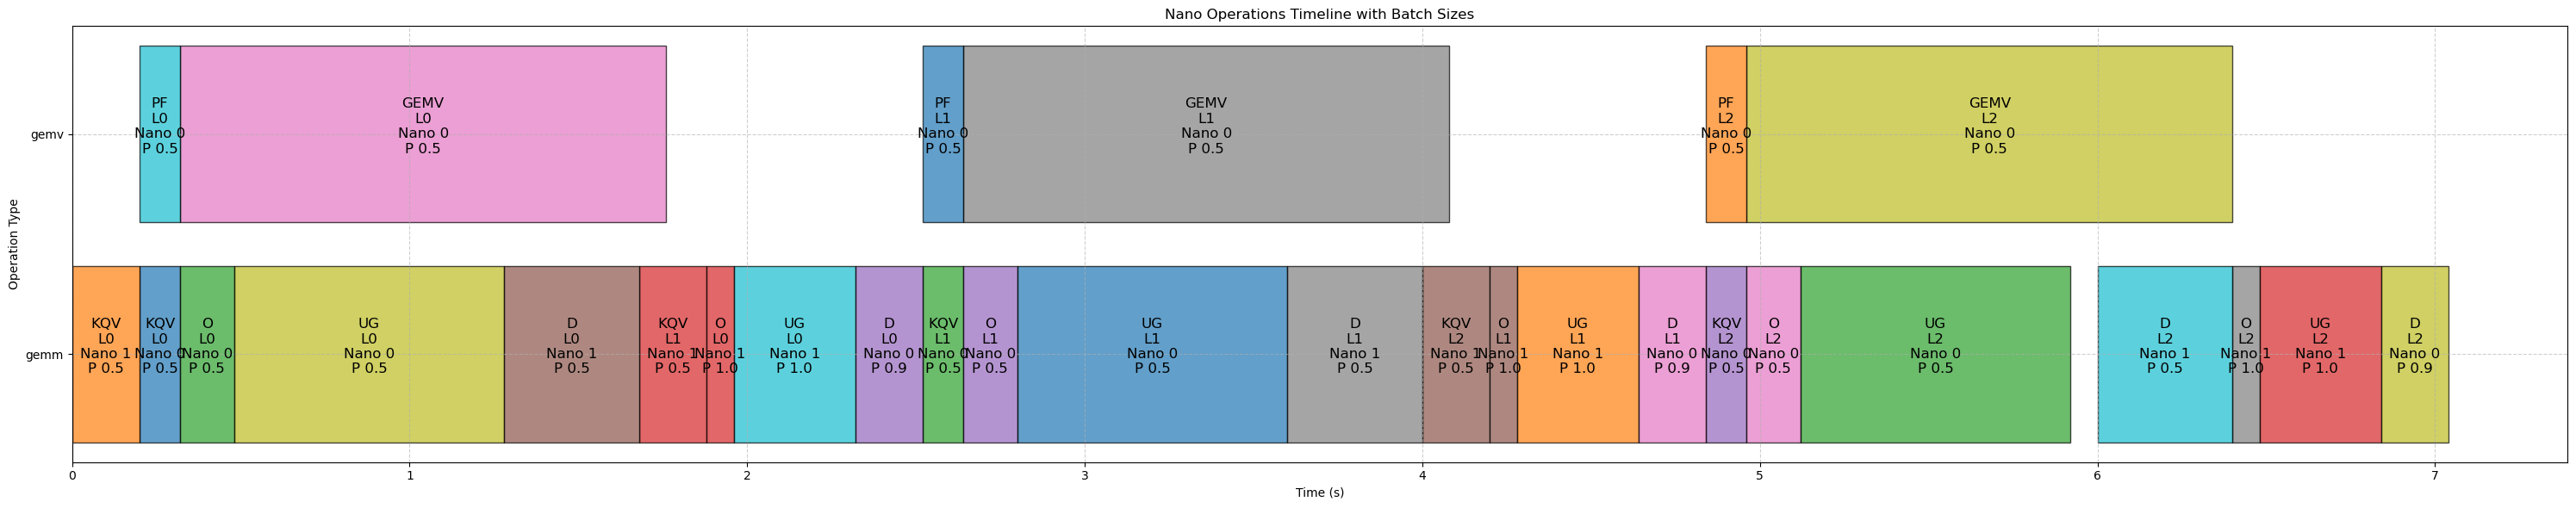

In [ ]:
# again, plot the schedule
from matplotlib import pyplot as plt

# Assuming you have a list of NanoOperation instances called nano_operations_list
# and each NanoOperation has the required attributes.

# Extract unique operation types
operation_types = sorted(set(n.operation.category for n in second_stage_nano_ops))
y_positions = {op_type: i for i, op_type in enumerate(operation_types)}

fig, ax = plt.subplots(figsize=(30, 6))

for n in second_stage_nano_ops:
    n_name = n.name
    # Access the optimized values of the variables
    start_time = schedule[n]['start_time']
    duration = schedule[n]['duration']
    op_type = n.operation.category  # Assuming 'category
    p = schedule[n]['gpu_utilization']

    y_position = y_positions[op_type]
    
    # Plot the operation as a horizontal bar
    ax.barh(y_position, duration, left=start_time, height=0.8, alpha=0.7, edgecolor="black")
    
    # Annotate with operation name and batch size
    label = f"{n.operation.name}\nL{n.layered_operation.layer}\nNano {n.idx}\nP {p}\n"
    ax.text(start_time + duration / 2, y_position, label, ha="center", va="center", color="black", fontsize=12)
    
# Set y-ticks and labels
ax.set_yticks(list(y_positions.values()))
ax.set_yticklabels(list(y_positions.keys()))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Operation Type")
ax.set_title("Nano Operations Timeline with Batch Sizes")
ax.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("nano_operations_timeline_second_stage.png")
plt.show()

    

In [ ]:
selected_sop = None
for sop in second_stage_nano_ops:
    if sop.name == "GEMV_2_0":
        selected_sop = sop
        break
print("start_time", schedule[selected_sop]['start_time'])
print("duration", schedule[selected_sop]['duration'])
print("finish_time", schedule[selected_sop]['finish_time'])
print("gpu_utilization", schedule[selected_sop]['gpu_utilization'])

# print isRunning variables
for p in selected_sop.p_choices:
    print(selected_sop.duration_units[p], selected_sop.p_vars[p].X)
    c = 0
    for t in range(100):
        if selected_sop.isrunning[p, t].X > 0.5:
            c += 1
            print(f"gpu utilization {p} at time {t} is running")
    print(f"gpu utilization {p} is running {c} times")


start_time 4.96
duration 1.44
finish_time 6.4
gpu_utilization 0.5
79 0.0
gpu utilization 0.1 is running 0 times
46 0.0
gpu utilization 0.3 is running 0 times
36 1.0
gpu utilization 0.5 is running 0 times
30 0.0
gpu utilization 0.7 is running 0 times
27 0.0
gpu utilization 0.9 is running 0 times
25 0.0
gpu utilization 1 is running 0 times


In [ ]:
# Validate dependencies
print('\nValidating Dependencies:')
dependencies_satisfied = True
for op in second_stage_nano_ops:
    if op in schedule:
        op_start = schedule[op]['start_time']
        op_finish = schedule[op]['finish_time']
        for dep_op in op.depend_on_nano_ops:
            if dep_op in schedule:
                dep_finish = schedule[dep_op]['finish_time']
                if op_start < dep_finish - 1e-6:
                    dependencies_satisfied = False
                    print(f'Dependency violation: Operation {op.name} starts at {op_start}, '
                            f'but dependent operation {dep_op.name} finishes at {dep_finish}')
if dependencies_satisfied:
    print('All dependencies are satisfied.')

# Validate resource constraints
print('\nValidating Resource Constraints:')
resource_violation = False
# Collect all time points where operations start or finish
time_points = set()
for operation in schedule.values():
    time_points.add(operation['start_time'])
    time_points.add(operation['finish_time'])
# Create a sorted list of time points
time_points = sorted(time_points)
# Check resource utilization between each pair of time points
for i in range(len(time_points) - 1):
    interval_start = time_points[i]
    interval_end = time_points[i + 1]
    total_gpu_utilization = 0
    for operation in schedule.values():
        op_start = operation['start_time']
        op_finish = operation['finish_time']
        if op_start < interval_end - 1e-6 and op_finish > interval_start + 1e-6:
            total_gpu_utilization += operation['gpu_utilization']
    if total_gpu_utilization > 1.0 + 1e-6:
        resource_violation = True
        print(f'Resource violation between time {interval_start} and {interval_end}: '
                f'Total GPU utilization is {total_gpu_utilization} (> 1)')
if not resource_violation:
    print('Resource constraints are satisfied at all times.')

# --- End Validation ---


Validating Dependencies:
All dependencies are satisfied.

Validating Resource Constraints:
Resource constraints are satisfied at all times.
